In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
df = pd.read_csv("mental_health_survey.csv")


'''print("========INFO========")
print(df.info())


print("========MISSING VALUES========")
print(df.isnull().sum())
'''


df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])
df['work_interfere'] = df['work_interfere'].fillna("Unknown")


age_data = df['Age']
age = age_data[(age_data >= 18) & (age_data <= 65)]
age_mode = age.mode()
df.loc[(df['Age'] < 18) | (df['Age'] > 65), 'Age'] = age_mode[0]


gender_data = df['Gender'].str.lower()
df['Gender'] = gender_data
df.loc[(df['Gender'] != "male") & (df['Gender'] != "female"), 'Gender'] = "Other"

df = df.drop(columns=['state', 'comments'])

print(df.isnull().sum())
print(df.describe())

df.to_csv("mental_health_survey_cleaned.csv")

Timestamp                    0
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64
               Age
count  1259.000000
mean     32.023034
std       7.181849
min      18.000000
25%      27.000000
50%      31.000000
75%      36.000000
max      65.000000


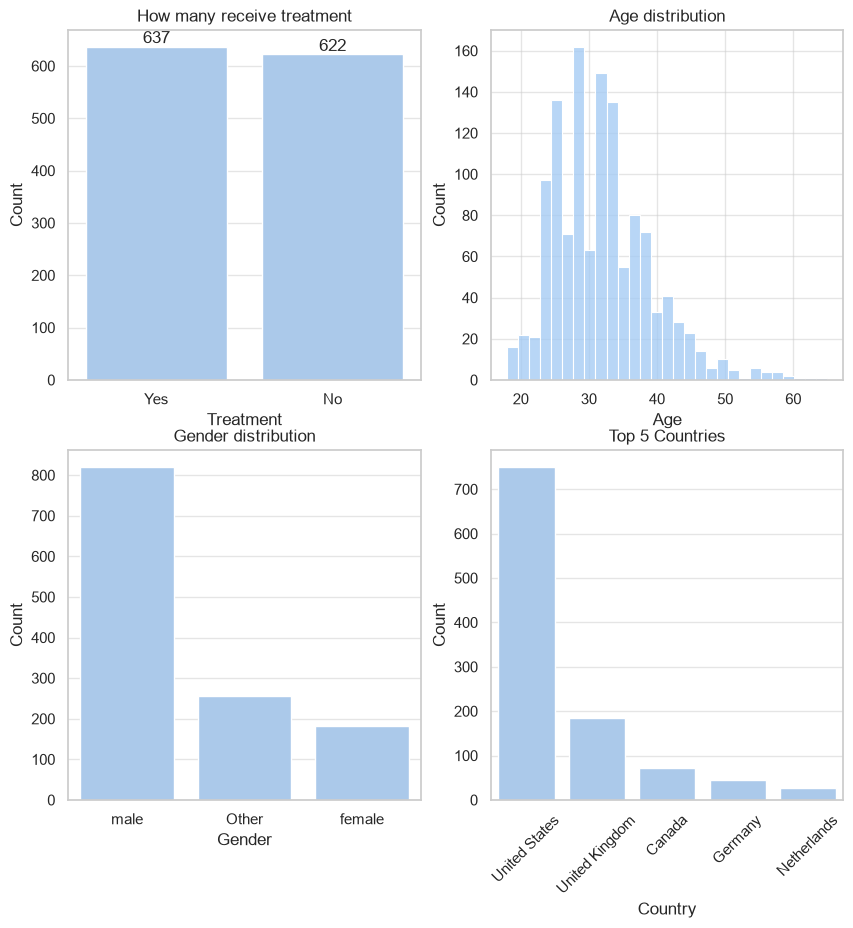

In [5]:
df = pd.read_csv("mental_health_survey_cleaned.csv")




sns.set_theme(style="whitegrid", palette="pastel")

fig, ax = plt.subplots(2,2, figsize=(10,10))


treat = df['treatment'].value_counts()

sns.barplot(x=treat.index, y=treat.values, ax=ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])
ax[0,0].set_xlabel("Treatment")
ax[0,0].set_ylabel("Count")
ax[0,0].set_title("How many receive treatment")


sns.histplot(data=df['Age'], ax=ax[0,1])
ax[0,1].set_xlabel("Age")
ax[0,1].set_ylabel("Count")
ax[0,1].set_title("Age distribution")




gender = df['Gender'].value_counts()
sns.barplot(data=gender, ax=ax[1,0])
ax[1,0].set_xlabel("Gender")
ax[1,0].set_ylabel("Count")
ax[1,0].set_title("Gender distribution")

country = df['Country'].value_counts()
country_top5 = country.head(5)

sns.barplot(data=country_top5, ax=ax[1,1])
ax[1,1].tick_params(axis='x', labelrotation=45)
ax[1,1].set_xlabel("Country")
ax[1,1].set_ylabel("Count")
ax[1,1].set_title("Top 5 Countries")

plt.show()

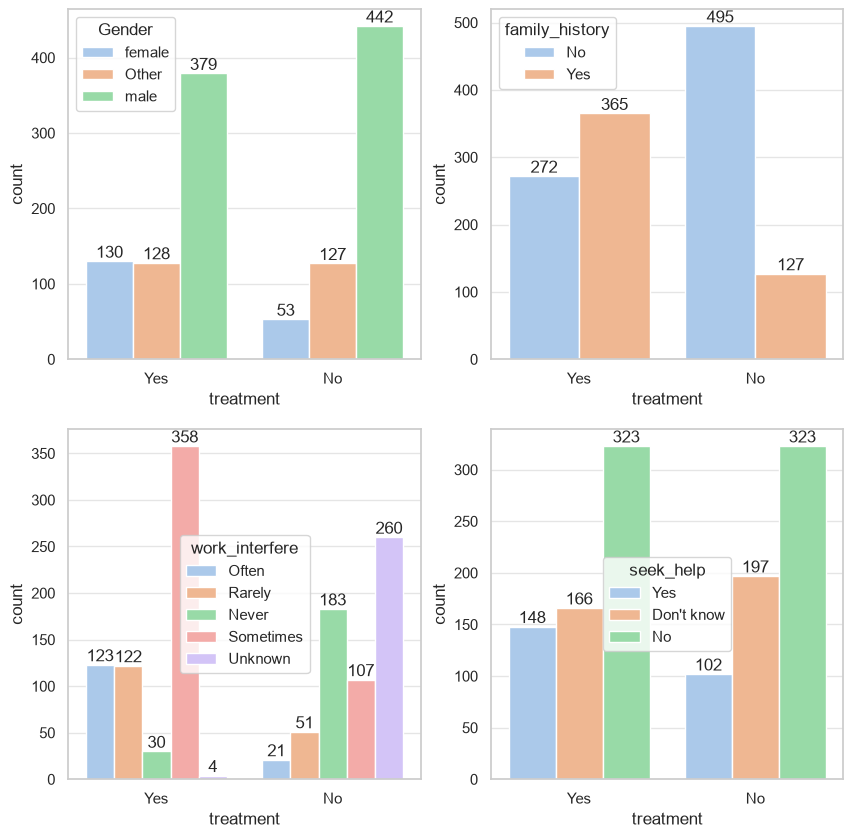

In [6]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
sns.countplot(data=df, x='treatment', hue='Gender', ax=ax[0,0])
for container in ax[0,0].containers:
    ax[0,0].bar_label(container)

sns.countplot(data=df, x='treatment', hue='family_history', ax=ax[0,1])
for container in ax[0,1].containers:
    ax[0,1].bar_label(container)

sns.countplot(data=df, x='treatment', hue='work_interfere', ax=ax[1,0])
for container in ax[1,0].containers:
    ax[1,0].bar_label(container)

sns.countplot(data=df, x='treatment', hue='seek_help', ax=ax[1,1])
for container in ax[1,1].containers:
    ax[1,1].bar_label(container)

<Axes: xlabel='treatment', ylabel='Age'>

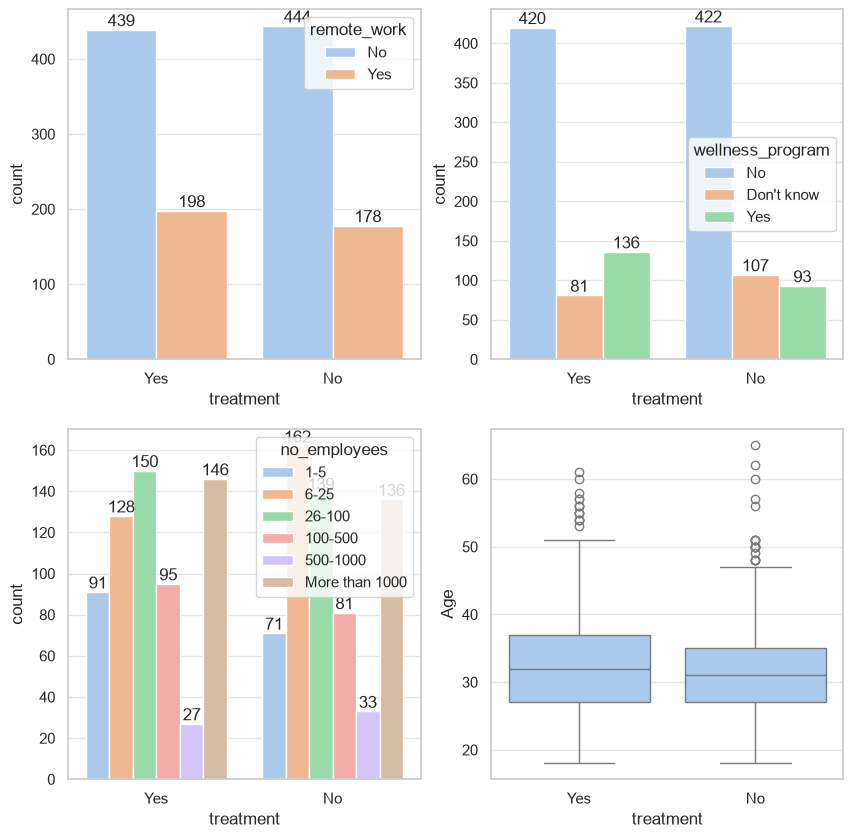

In [7]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
sns.countplot(data=df, x='treatment', hue='remote_work', ax=ax[0,0])
for container in ax[0,0].containers:
    ax[0,0].bar_label(container)

sns.countplot(data=df, x='treatment', hue='wellness_program', ax=ax[0,1])
for container in ax[0,1].containers:
    ax[0,1].bar_label(container)


emp_order = ["1-5", "6-25", "26-100", "100-500", "500-1000", "More than 1000"]
sns.countplot(data=df, x='treatment', hue='no_employees', ax=ax[1,0],
              hue_order=emp_order)
for container in ax[1,0].containers:
    ax[1,0].bar_label(container)

sns.boxplot(data=df, x='treatment', y='Age', ax=ax[1,1])


C:\Users\Josh\AppData\Local\Temp\ipykernel_10352\1090489143.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


treatment                    1.000000
family_history               0.377918
care_options                 0.236578
benefits                     0.226140
obs_consequence              0.156972
anonymity                    0.142889
mental_health_interview      0.098413
wellness_program             0.094713
seek_help                    0.089935
Country                      0.077681
Age                          0.068895
coworkers                    0.068433
mental_vs_physical           0.062642
Timestamp                    0.062499
Unnamed: 0                   0.062447
leave                        0.061549
phys_health_interview        0.051859
mental_health_consequence    0.030221
remote_work                  0.026937
self_employed                0.020493
phys_health_consequence     -0.008933
tech_company                -0.031525
work_interfere              -0.035881
supervisor                  -0.036199
no_employees                -0.050114
Gender                      -0.069565
Name: treatm

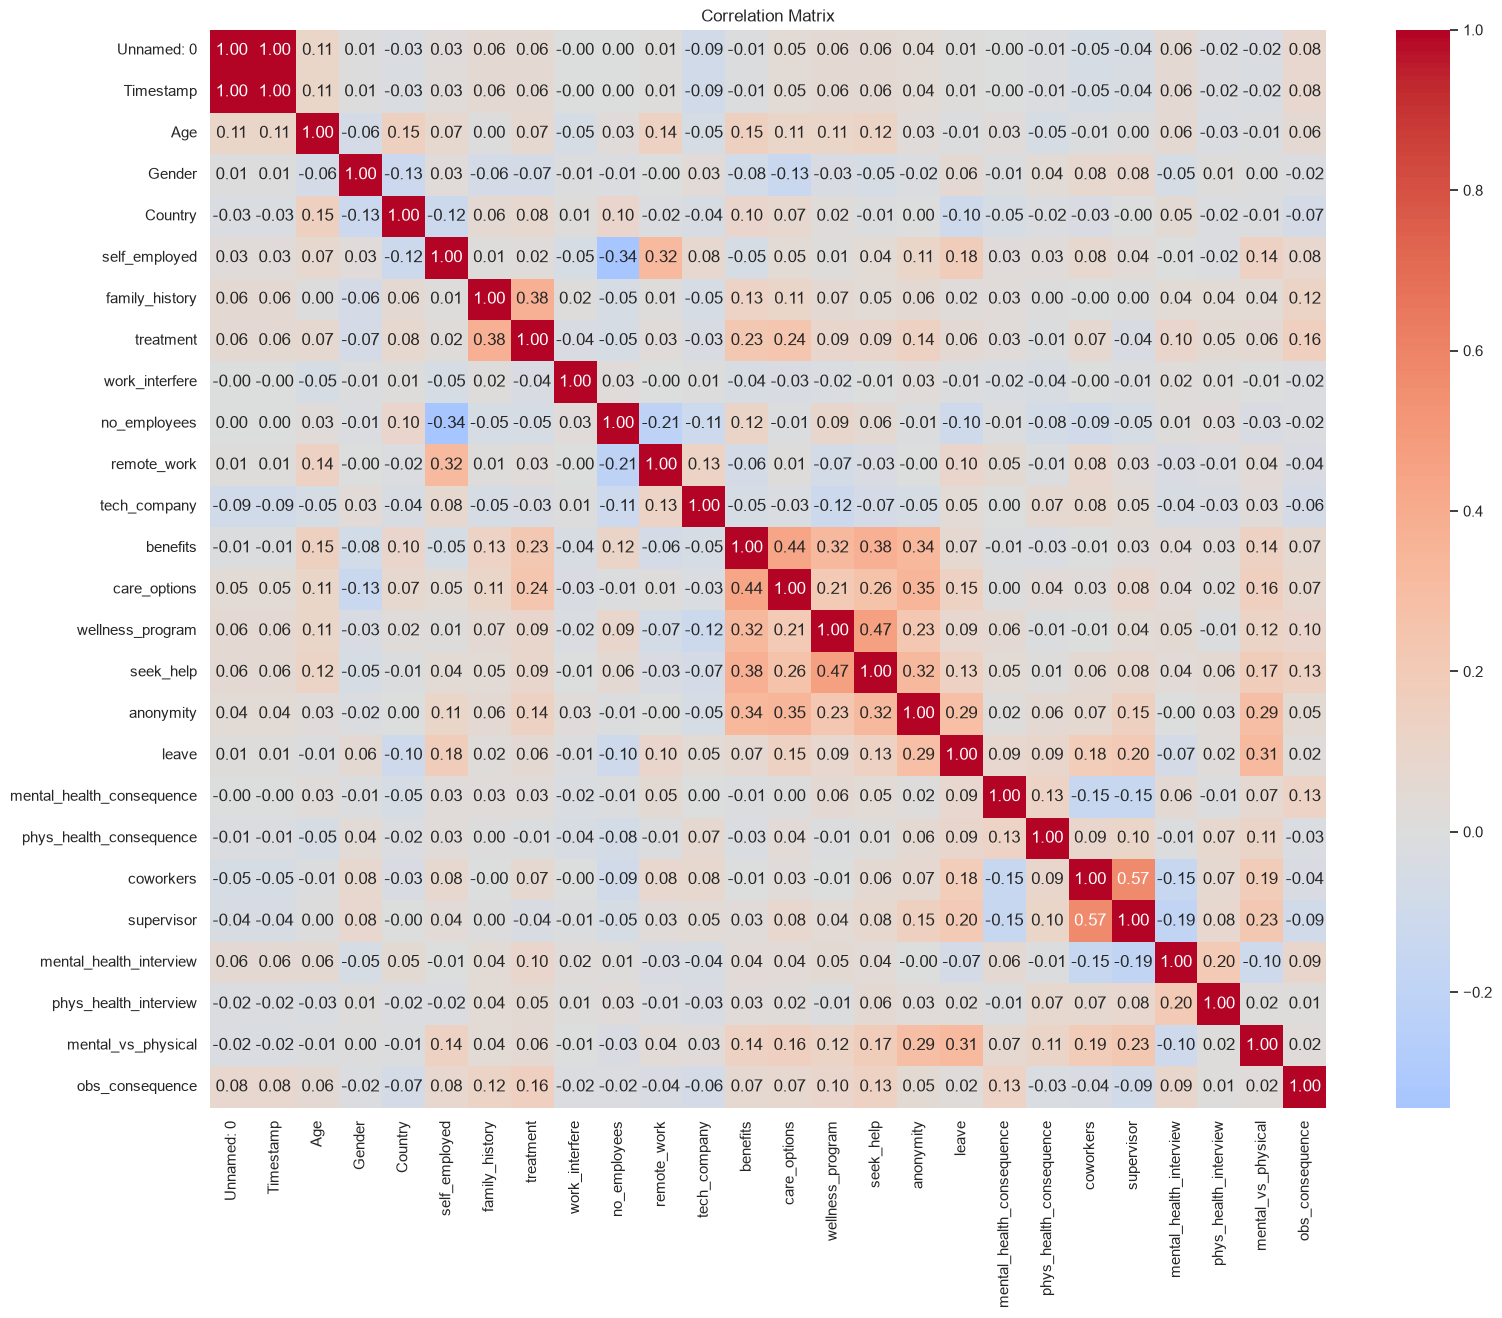

In [8]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr_matrix = df_encoded.corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
print(corr_matrix['treatment'].sort_values(ascending=False))
plt.show()

In [9]:
work_int = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Unknown": 4}
df['work_interfere'] = df['work_interfere'].map(work_int)

df['treatment'] = df['treatment'].map({"Yes": 1, "No": 0})
df = pd.get_dummies(df, columns=['family_history', 'care_options', 'benefits', 'Gender'])
df = df.drop(columns=["Unnamed: 0"])
df.to_csv("mental_health_survey_engineered4.csv")
print(df.columns)


Index(['Timestamp', 'Age', 'Country', 'self_employed', 'treatment',
       'work_interfere', 'no_employees', 'remote_work', 'tech_company',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'family_history_No',
       'family_history_Yes', 'care_options_No', 'care_options_Not sure',
       'care_options_Yes', 'benefits_Don't know', 'benefits_No',
       'benefits_Yes', 'Gender_Other', 'Gender_female', 'Gender_male'],
      dtype='str')


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
df = pd.read_csv("mental_health_survey_engineered4.csv")
df.drop(columns=['Unnamed: 0'], inplace=True)


X = df.drop(columns=['treatment']).select_dtypes(exclude=['object', 'str'])
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)
clf.predict(X_test)
score = clf.score(X_test, y_test)
print(score)
print(classification_report(y_test, y_pred=clf.predict(X_test), ))

0.6944444444444444
              precision    recall  f1-score   support

           0       0.72      0.66      0.69       129
           1       0.67      0.73      0.70       123

    accuracy                           0.69       252
   macro avg       0.70      0.70      0.69       252
weighted avg       0.70      0.69      0.69       252



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
df = pd.read_csv("mental_health_survey_engineered4.csv")

X = df.drop(columns=['treatment','Unnamed: 0']).select_dtypes(exclude=['object', 'str'])
print(X.dtypes)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
score = clf.score(X_test, y_test)
print(score)
print(classification_report(y_test, y_pred=clf.predict(X_test), ))

Age                      int64
work_interfere           int64
family_history_No         bool
family_history_Yes        bool
care_options_No           bool
care_options_Not sure     bool
care_options_Yes          bool
benefits_Don't know       bool
benefits_No               bool
benefits_Yes              bool
Gender_Other              bool
Gender_female             bool
Gender_male               bool
dtype: object
0.746031746031746
              precision    recall  f1-score   support

           0       0.77      0.71      0.74       129
           1       0.72      0.78      0.75       123

    accuracy                           0.75       252
   macro avg       0.75      0.75      0.75       252
weighted avg       0.75      0.75      0.75       252



In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
df = pd.read_csv("mental_health_survey_engineered4.csv")

X = df.drop(columns=['treatment','Unnamed: 0' ]).select_dtypes(exclude=['object', 'str'])
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = XGBClassifier(random_state=42).fit(X_train, y_train)
score = clf.score(X_test, y_test)
print(score)
print(classification_report(y_test, y_pred=clf.predict(X_test), ))

0.7698412698412699
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       129
           1       0.74      0.80      0.77       123

    accuracy                           0.77       252
   macro avg       0.77      0.77      0.77       252
weighted avg       0.77      0.77      0.77       252



Age                      int64
work_interfere           int64
family_history_No         bool
family_history_Yes        bool
care_options_No           bool
care_options_Not_sure     bool
care_options_Yes          bool
benefits_Don_t_know       bool
benefits_No               bool
benefits_Yes              bool
Gender_Other              bool
Gender_female             bool
Gender_male               bool
dtype: object
[LightGBM] [Info] Number of positive: 514, number of negative: 493
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 66
[LightGBM] [Info] Number of data points in the train set: 1007, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.510427 -> initscore=0.041714
[LightGBM] [Info] Start training from score 0.041714
0.7936507936507936
              p

C:\Users\Josh\Desktop\nasa\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


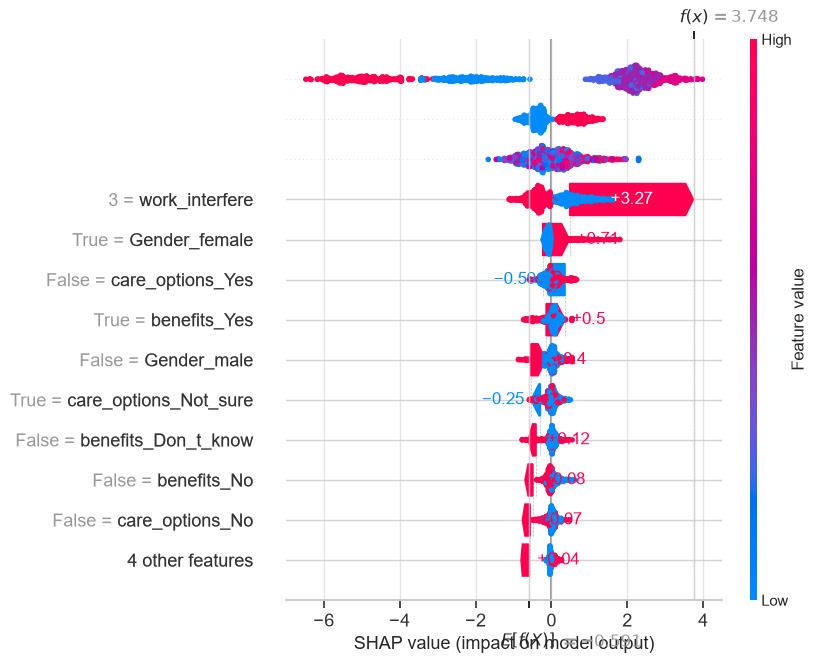

In [13]:
# best model

import shap
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
df = pd.read_csv("mental_health_survey_engineered4.csv")
df.columns = df.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

X = df.drop(columns=['treatment', 'Unnamed__0']).select_dtypes(exclude=['object', 'str'])
print(X.dtypes)
y = df['treatment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LGBMClassifier(random_state=42).fit(X_train, y_train)
score = clf.score(X_test, y_test)
print(score)
print(classification_report(y_test, y_pred=clf.predict(X_test), ))

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)


shap.summary_plot(shap_values, X, show=False)
plt.savefig("assets/shap_summary.png", dpi=300, bbox_inches='tight')


shap_explanation = explainer(X)

shap.plots.waterfall(shap_explanation[0])
plt.savefig("assets/shap_waterfall.png", dpi=300, bbox_inches='tight')
plt.close()

shap.initjs()

shap.plots.force(shap_explanation[0])

import joblib


joblib.dump(clf, 'my_model.joblib')


loaded_model = joblib.load('my_model.joblib')

In [14]:
shap.plots.waterfall(shap_explanation[0], show=False)
plt.savefig("assets/shap_waterfall.png", dpi=300, bbox_inches='tight')
plt.close()